# Assessing the Federal Reserve's Mandate Fulfillment: Inflation and Unemployment

### Objective
The Federal Reserve is tasked with a dual mandate from Congress:
1. **Control Inflation** - Achieved through raising or lowering the federal funds rate.
2. **Maintain Low Unemployment** - Ensuring that unemployment levels stay within a reasonable range.

However, these two goals can seem contradictory, as raising interest rates to curb inflation can also lead to increased unemployment. This notebook explores data from the past 25 years to assess whether the Federal Reserve has successfully balanced these objectives.

We will use the following data:
- **Consumer Price Index (CPI)** from the **Bureau of Labor Statistics (BLS)**, which measures inflation.
- **Federal Funds Rate** from the **Federal Reserve Economic Data (FRED)** API.
- **Unemployment Rate** from the **Bureau of Labor Statistics (BLS)**.

### Data Sourcing

We will pull data from the last 25 years using the BLS and FRED APIs, then plot the results to visualize trends in inflation (CPI), the federal funds rate, and unemployment over time.


In [70]:
# Import necessary libraries
import requests
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred

# Get your API keys
fred_api_key = '9399606b2ceeaa0a58491d4e6b122b15'
bls_api_key = '66993dba6faf49dfa7ae3cc335de3f9c'

# Set your FRED API key
fred = Fred(api_key=fred_api_key)

# Function to fetch BLS data in two parts (due to the 20-year limit)
def fetch_bls_series_two_parts(series_id, start_year, mid_year, end_year, api_key):
    url = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'

    # First 20-year data request
    payload_1 = {
        "seriesid": [series_id],
        "startyear": str(start_year),
        "endyear": str(mid_year),
        "registrationkey": api_key
    }
    response_1 = requests.post(url, json=payload_1)
    if response_1.status_code == 200:
        data_1 = response_1.json()['Results']['series'][0]['data']
        bls_data_1 = pd.Series({f"{item['year']}-{item['period'][1:]}": float(item['value']) for item in data_1 if item['period'] != 'M13'})
    else:
        print(f"Error fetching BLS data for first part: {response_1.status_code}")
        return pd.Series()

    # Remaining 5 years data request
    payload_2 = {
        "seriesid": [series_id],
        "startyear": str(mid_year + 1),
        "endyear": str(end_year),
        "registrationkey": api_key
    }
    response_2 = requests.post(url, json=payload_2)
    if response_2.status_code == 200:
        data_2 = response_2.json()['Results']['series'][0]['data']
        bls_data_2 = pd.Series({f"{item['year']}-{item['period'][1:]}": float(item['value']) for item in data_2 if item['period'] != 'M13'})
    else:
        print(f"Error fetching BLS data for second part: {response_2.status_code}")
        return pd.Series()

    # Combine both parts
    combined_bls_data = pd.concat([bls_data_1, bls_data_2]).sort_index()
    combined_bls_data.index = pd.to_datetime(combined_bls_data.index)
    
    return combined_bls_data

# Define the date range (last 25 years)
start_year = 1998
mid_year = 2017
end_year = 2024

# Get the Federal Funds Rate from FRED (monthly data)
fed_funds_rate = fred.get_series('FEDFUNDS', observation_start=f'{start_year}-01-01', observation_end=f'{end_year}-12-01')

# Get CPI and Unemployment Rate from BLS
cpi_bls = fetch_bls_series_two_parts('CUUR0000SA0', start_year, mid_year, end_year, bls_api_key)  # CPI
unemployment_rate_bls = fetch_bls_series_two_parts('LNS14000000', start_year, mid_year, end_year, bls_api_key)  # Unemployment Rate

# Combine into a DataFrame for easy manipulation
data = pd.DataFrame({
    'Federal Funds Rate': fed_funds_rate,
    'CPI': cpi_bls,
    'Unemployment Rate': unemployment_rate_bls
})


In [71]:
# Check for missing values
missing_data = data.isna().sum()
print("Missing values in each column:\n", missing_data)

# Print rows with missing values
print("Rows with missing values:\n", data[data.isna().any(axis=1)])

Missing values in each column:
 Federal Funds Rate    0
CPI                   0
Unemployment Rate     0
dtype: int64
Rows with missing values:
 Empty DataFrame
Columns: [Federal Funds Rate, CPI, Unemployment Rate]
Index: []


### Data Overview and Initial Findings

Before we visualize the data, let's take a quick look at the first few rows to confirm that we've successfully pulled data for all three indicators over the past 25 years.

In [72]:
data.head(20)

,Federal Funds Rate,CPI,Unemployment Rate
1998-01-01,5.56,161.6,4.6
1998-02-01,5.51,161.9,4.6
1998-03-01,5.49,162.2,4.7
1998-04-01,5.45,162.5,4.3
1998-05-01,5.49,162.8,4.4
1998-06-01,5.56,163.0,4.5
1998-07-01,5.54,163.2,4.5
1998-08-01,5.55,163.4,4.5
1998-09-01,5.51,163.6,4.6
1998-10-01,5.07,164.0,4.5


### Visualization: Inflation, Unemployment, and Federal Funds Rate (1999 - 2024)

Let's now visualize the three key indicators:
- **Federal Funds Rate**: Controlled by the Federal Reserve to combat inflation and unemployment.
- **Consumer Price Index (CPI)**: A measure of inflation.
- **Unemployment Rate**: The percentage of the labor force that is unemployed and actively seeking work.

We'll use a multi-plot layout to view these time series together and assess whether the Federal Reserve has managed to control inflation while keeping unemployment low.

In [73]:
# Calculate yearly change for CPI
data['CPI_change'] = data['CPI'].pct_change(periods=12) * 100  # Percentage change year-over-year

# Remove year 1998 as it was only included to get the first percentage change
data = data.loc['1999':]

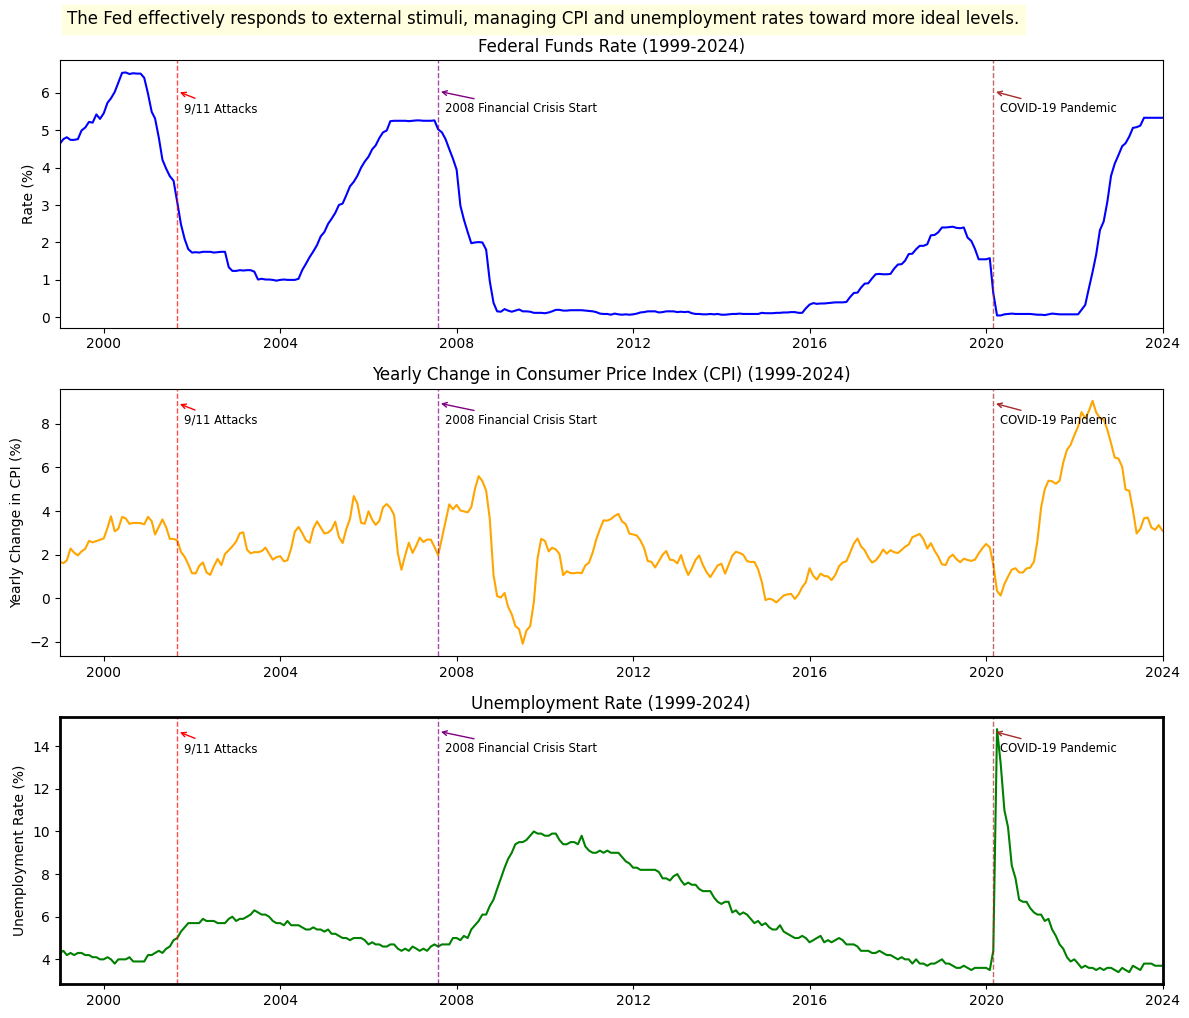

In [77]:
# Important historical events with colors
events = {
    '9/11 Attacks': {'date': '2001-09-01', 'color': 'red'},
    '2008 Financial Crisis Start': {'date': '2007-08-01', 'color': 'purple'},  # Start of the crisis
    #'2008 Financial Crisis Peak': {'date': '2008-09-01', 'color': 'purple'},   # Peak of the crisis
    'COVID-19 Pandemic': {'date': '2020-03-01', 'color': 'brown'}
}

# Adding a sentence with main findings at the top of the figure
main_findings = "The Fed effectively responds to external stimuli, managing CPI and unemployment rates toward more ideal levels."

# Set x-axis limit
start_year = pd.to_datetime('1999-01-01')
end_year = pd.to_datetime('2024-01-01')

# Plotting the data
plt.figure(figsize=(12, 10))

# Add the main findings text at the top
plt.figtext(0.06, 0.999, main_findings, wrap=True, horizontalalignment='left', fontsize=12, color='black', backgroundcolor='lightyellow')

# Plot Federal Funds Rate
plt.subplot(3, 1, 1)
plt.plot(data.index, data['Federal Funds Rate'], label='_nolegend_', color='blue')  # Remove from legend
for label, event in events.items():
    event_date = pd.to_datetime(event['date'])
    plt.axvline(event_date, color=event['color'], linestyle='--', linewidth=1, alpha=0.7)
    plt.annotate(label, xy=(event_date, data['Federal Funds Rate'].max() - 0.5), xytext=(5, -15),
                 textcoords='offset points', arrowprops=dict(arrowstyle='->', color=event['color']),
                 fontsize='small', color='black')
plt.title('Federal Funds Rate (1999-2024)')
plt.ylabel('Rate (%)')
plt.xlim([start_year, end_year])  # Set x-axis limit

# Plot Yearly Change in CPI (Consumer Price Index)
plt.subplot(3, 1, 2)
plt.plot(data.index, data['CPI_change'], label='_nolegend_', color='orange')  # Remove from legend
for label, event in events.items():
    event_date = pd.to_datetime(event['date'])
    plt.axvline(event_date, color=event['color'], linestyle='--', linewidth=1, alpha=0.7)
    plt.annotate(label, xy=(event_date, data['CPI_change'].max() - 0.1), xytext=(5, -15),
                 textcoords='offset points', arrowprops=dict(arrowstyle='->', color=event['color']),
                 fontsize='small', color='black')
plt.title('Yearly Change in Consumer Price Index (CPI) (1999-2024)')
plt.ylabel('Yearly Change in CPI (%)')
plt.xlim([start_year, end_year])  # Set x-axis limit

# Plot Unemployment Rate
plt.subplot(3, 1, 3)
plt.plot(data.index, data['Unemployment Rate'], label='_nolegend_', color='green')  # Remove from legend
for label, event in events.items():
    event_date = pd.to_datetime(event['date'])
    plt.axvline(event_date, color=event['color'], linestyle='--', linewidth=1, alpha=0.7)
    plt.annotate(label, xy=(event_date, data['Unemployment Rate'].max() - 0.1), xytext=(5, -15),
                 textcoords='offset points', arrowprops=dict(arrowstyle='->', color=event['color']),
                 fontsize='small', color='black')
plt.title('Unemployment Rate (1999-2024)')
plt.ylabel('Unemployment Rate (%)')
plt.xlim([start_year, end_year])  # Set x-axis limit

plt.tight_layout()
plt.show()

### Analysis and Discussion

#### Federal Funds Rate and Inflation (CPI)
The Federal Reserve typically raises interest rates (Federal Funds Rate) in response to rising inflation (as measured by the CPI). In periods where inflation rises sharply, the Federal Reserve tends to increase the rate to cool off the economy and prevent inflation from spiraling out of control. We can observe this pattern during specific periods, particularly in the early 2000s and around 2022.

#### Federal Funds Rate and Unemployment
Raising interest rates can have a dampening effect on employment. When interest rates rise, it becomes more expensive for businesses to borrow, invest, and hire. As a result, unemployment may rise following rate hikes. We see this during recessionary periods like 2008-2009, where the unemployment rate spiked sharply following rate adjustments.

#### Mandate Fulfillment
From this data, we can observe that:
- The Federal Reserve tends to increase interest rates in response to rising inflation, which suggests they are actively trying to control inflation.
- However, periods of high interest rates (intended to curb inflation) often correspond with rising unemployment, highlighting the inherent conflict between these two objectives.
- As a whole though, we can see that the large changes in inflation or unemployment are almost always caused by outside stimuli that aren't in the Federal Reserve's ability to stop. The Federal Reserve does seem to do a good job in bringing those factors back to more ideal rates.

In conclusion, while the Federal Reserve has been able to control inflation during certain periods, this has often come at the cost of rising unemployment, making it difficult to perfectly balance its dual mandate. The challenge of managing these contradictory objectives is clearly evident in the data. In the long run, the Federal reserve does eem to understand these conflicting objectives and ensures no major fluctuations in either to the best of its ability.
